In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import generate_lorentz as gl
import generate_data as gd
import classify_data as cd
import efficient_data_generation as ed
import os
import importlib
importlib.reload(cd)
importlib.reload(ed)

<module 'efficient_data_generation' from '/home/gabriel/Insync/gpe@berkeley.edu/Google Drive/Seconcephalon/Projects/LEPRECHAUN/Analytis Laboratory/ML Peak Tracker/efficient_data_generation.py'>

In [4]:
# Generate a large simple data set
simple_data_dir = os.path.join(os.getcwd(), 'generated_simple_data')
simp = ed.make_simple_data_set(50000)
simp_set = ed.convert_simple_data_set(simp)

Converting Lorentzians: [########################################] 401853/401853

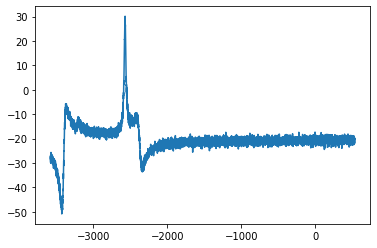

In [36]:
# Preview a sample of generated data
background_params, lorentz_params, f, v = gl.generate_data()
plt.plot(f, v)

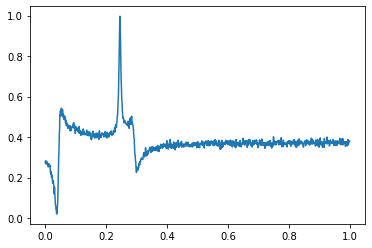

In [37]:
# Preview that sample, but normalized
f_norm = cd.normalize_1d(f)
v_norm = cd.normalize_1d(v)
plt.plot(f_norm, v_norm)

In [23]:
# Decide where to generate data and load it from
root = os.getcwd()
train_dir = os.path.join(root, 'generated_data_train')
test_dir = os.path.join(root, 'generated_data_test')

In [9]:
# Generate a testing data set and training data set
gd.generate_data_set(root, 'generated_data_train', include_noise=True, count=1000)
gd.generate_data_set(root, 'generated_data_test', include_noise=True, count=1000)

In [24]:
# Load those testing and training data sets
train_data_set = gd.load_data_set(train_dir)
test_data_set = gd.load_data_set(test_dir)

In [7]:
# Preprocess/normalize the data sets so the number of clusters can be detected
count_labels, count_data = cd.pre_process_for_counting(simp_set)

Labeling: [########################################] 50000/50000

In [8]:
# Set up the cluster counting model
cluster_count_model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(1024),
    # keras.layers.Dense(1024),
    # keras.layers.Dense(1024),
    # keras.layers.Dense(1024),
    # keras.layers.Dense(32),
    # keras.layers.Dense(1024),
    # keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(128)
])

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [9]:
# Compile the cluster counting model
cluster_count_model.compile(optimizer='Adadelta',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
# Fit the cluster counting model
cluster_count_model.fit(count_data, count_labels, epochs=100)

Epoch 1/100
50000/50000 [==============================] - 11s 227us/sample - loss: 2.2471 - acc: 0.1574
Epoch 2/100
50000/50000 [==============================] - 11s 229us/sample - loss: 2.2463 - acc: 0.1553
Epoch 3/100
50000/50000 [==============================] - 12s 231us/sample - loss: 2.2455 - acc: 0.1576
Epoch 4/100
50000/50000 [==============================] - 12s 230us/sample - loss: 2.2453 - acc: 0.1578
Epoch 5/100
50000/50000 [==============================] - 12s 231us/sample - loss: 2.2442 - acc: 0.1575
Epoch 6/100
50000/50000 [==============================] - 11s 230us/sample - loss: 2.2433 - acc: 0.1589
Epoch 7/100
50000/50000 [==============================] - 12s 231us/sample - loss: 2.2432 - acc: 0.1586
Epoch 8/100
50000/50000 [==============================] - 11s 229us/sample - loss: 2.2427 - acc: 0.1581
Epoch 9/100
50000/50000 [==============================] - 12s 231us/sample - loss: 2.2421 - acc: 0.1580
Epoch 10/100
50000/50000 [=============================

In [14]:
# Preprocess/normalize the data sets so the class of each clusters can be detected
class_labels, class_data = cd.pre_process_for_classifying(simp_set)

####################.] 49702/50000Classifying: [#######################################.] 49703/50000Classifying: [#######################################.] 49704/50000Classifying: [#######################################.] 49705/50000Classifying: [#######################################.] 49706/50000Classifying: [#######################################.] 49707/50000Classifying: [#######################################.] 49708/50000Classifying: [#######################################.] 49709/50000Classifying: [#######################################.] 49710/50000Classifying: [#######################################.] 49711/50000Classifying: [#######################################.] 49712/50000Classifying: [#######################################.] 49713/50000Classifying: [#######################################.] 49714/50000Classifying: [#######################################.] 49715/50000Classifying: [#######################################.] 49716/50000Classifying: [##############

In [18]:
# Set up the cluster classifying model
cluster_class_model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(32),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(128)
])

In [19]:
# Compile the cluster classifying model
cluster_class_model.compile(optimizer='Adamax',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

In [20]:
# Fit the cluster classifying model
cluster_class_model.fit(class_data, class_labels, epochs=10)

Epoch 1/10
263312/263312 [==============================] - 159s 605us/sample - loss: 1.0384 - acc: 0.6727
Epoch 2/10
263312/263312 [==============================] - 159s 604us/sample - loss: 0.9856 - acc: 0.6738
Epoch 3/10
263312/263312 [==============================] - 159s 604us/sample - loss: 0.9840 - acc: 0.6738
Epoch 4/10
263312/263312 [==============================] - 160s 607us/sample - loss: 0.9834 - acc: 0.6738
Epoch 5/10
263312/263312 [==============================] - 160s 607us/sample - loss: 0.9831 - acc: 0.6738
Epoch 6/10
263312/263312 [==============================] - 160s 608us/sample - loss: 0.9829 - acc: 0.6738
Epoch 7/10
263312/263312 [==============================] - 160s 608us/sample - loss: 0.9828 - acc: 0.6738
Epoch 8/10
263312/263312 [==============================] - 160s 607us/sample - loss: 0.9827 - acc: 0.6738
Epoch 9/10
263312/263312 [==============================] - 160s 608us/sample - loss: 0.9825 - acc: 0.6738
Epoch 10/10
263312/263312 [==========

In [36]:
# Preprocess/normalize the data sets so the number of clusters can be detected
test_count_labels, test_count_data = cd.pre_process_for_counting(test_data_set)

Labeling: [########################################] 1000/1000

In [26]:
test_class_labels, test_class_data = cd.pre_process_for_classifying(test_data_set)

Classifying: [########################################] 1000/1000

In [37]:
count_loss, count_acc = cluster_count_model.evaluate(test_count_data, test_count_labels)

1000/1000 [==============================] - 0s 76us/sample - loss: 2.2536 - acc: 0.1410


In [27]:
class_loss, class_acc = cluster_class_model.evaluate(test_class_data, test_class_labels)

5240/5240 [==============================] - 1s 113us/sample - loss: 0.9660 - acc: 0.6802


In [38]:
count_probability_model = tf.keras.Sequential([cluster_count_model, tf.keras.layers.Softmax()])

In [29]:
class_probability_model = tf.keras.Sequential([cluster_class_model, tf.keras.layers.Softmax()])

In [39]:
count_predictions = count_probability_model.predict(test_count_data)

In [30]:
class_predictions = class_probability_model.predict(test_class_data)

In [41]:
def plot_count(i, count_predictions, count_label, count_data):
    true_label = int(count_label[i][0])
    predictions_array = count_predictions[i]
    v = count_data[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    f = np.linspace(0, 1, 1024)
    plt.plot(f, v)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    elif np.abs(predicted_label - true_label) == 1:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(str(predicted_label) + ' lorentzian cluster:', 100*np.max(predictions_array), str(true_label)), color=color)

def plot_value_array(i, count_predictions, count_label):
    predictions_array = count_predictions[i]
    true_label = int(count_label[i][0])
    plt.grid(False)
    plt.xticks([])
    plt.yticks([0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
    thisplot = plt.bar(range(32), predictions_array[0:32])
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

def plot_count_result(i, count_predictions, count_label, count_data):
    plt.figure(figsize=(20,6))
    plt.subplot(1,2,1)
    plot_count(i, count_predictions, count_label, count_data)
    plt.subplot(1,2,2)
    plot_value_array(i, count_predictions, count_label)

In [33]:
def preview_data(i, data_set):
    lorentz_params = data_set[1][i]
    data = data_set[2][i]
    (f, v) = cd.separate_data(data)
    f = cd.normalize_1d(f, (0,1,1024))
    v = cd.normalize_1d(v, (0,1,1024))
    plt.plot(f, v)
    print(cd.disect_lorentz_params_array(lorentz_params)[0])

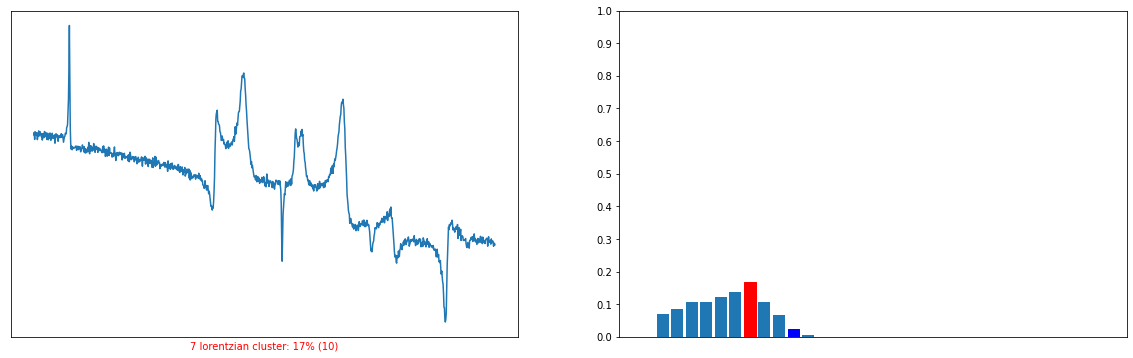

In [40]:
plot_count_result(13, count_predictions, test_count_labels, test_count_data)

In [42]:
plot_count_result(13, class_predictions, test_class_labels, test_class_data)

TypeError: tuple indices must be integers or slices, not numpy.float64

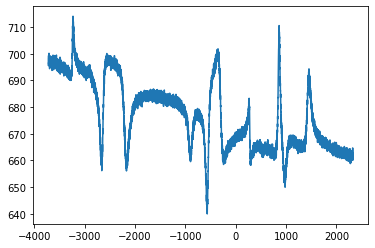

In [51]:
# Preview a sample of generated data
background_params, lorentz_params, f, v = gl.generate_data()
plt.plot(f, v)

In [52]:
# Preview the current Lorentzian separations
da = cd.merge_data(f, v)
frl = cd.disect_lorentz_params_array(lorentz_params)[1]
t = cd.partition_data_2d(da, frl, lorentz_params)[0]
print(cd.partition_data_2d(da, frl, lorentz_params)[1])
print(cd.partition_data_2d(da, frl, lorentz_params)[1].shape[0])
x = np.linspace(0,1,1024)

[[1.]
 [2.]
 [1.]
 [1.]
 [2.]
 [1.]
 [1.]
 [2.]
 [1.]]
9


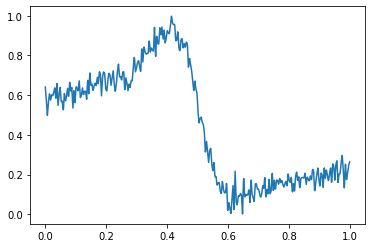

In [59]:
plt.plot(x, t[5])